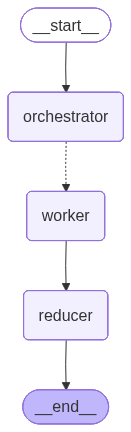

In [ ]:
#1st stage 
import operator # recuder 

from typing import TypedDict,Annotated,List
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from pydantic import Field, BaseModel # field to add extra description to the variable 
from langgraph.types import Send
from typing import Literal
from langchain_core.messages import SystemMessage,HumanMessage


#plan/task schema or pydantic object, used to define  schema 
class Task(BaseModel): #for each task it has 
    id:str
    title: str

    goal:str =Field(...,description='One sentance describing what the reader should be able to do/understad after this section')

    bullets:List[str]=Field(...,min_length=3,max_length=5,description="3-5 concrete, non-overlapping subpoints to cover in this section") # we will add some bullets the orchestrator which is making plan he will add 2-3 pointers that in this section which points should be covered we are addind more detailing

    target_words:int=Field(...,description="Target words count for this section(120-450)") # the orchestrator will also tell the target words for each section how much shoukd be there in each section

    section_type: Literal["intro","core","examples","checklists","common_mistakes","conclusions"]= Field(...,description="use 'common_mistakes' exactly once in the plan") # adding type means this section will be intro or core or examples of the blog topic or conclusion

    brief:str = Field(..., description=" what to cover" )

class Plan(BaseModel):
    blog_title: str

    audience:str=Field(...,description="Who this blog is for")

    task: list[Task]

    tone:str=Field(...,description="Writing tone(for example ,pratical,crisp)")


#state 
class State(TypedDict):
    topic :str # our user will give the topic
    plan: Plan # generated from orchestrator node  
    #reducer =results from workers get concatenated  automatically 
    sections : Annotated[list[str], operator.add] # in section we will have every worker's output and we will add them all this worker works on different  section means it will write the section(it will be a string) and sum this section to make a blog and this will be stored on the md file this combined string is stored in sections  and to add them we are using reducer function, i worker for each sections and combine them becomes sections operator.add=reducer function
    final :str #will store final blog after merging the section 

    

llm=ChatGroq(model="openai/gpt-oss-120b")


#nodes
def orchestrator(state:State) -> dict:
        planner=llm.with_structured_output(Plan)
    
        plan = planner.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a senior technical writer and developer advocate. Your job is to produce a "
                        "highly actionable outline for a technical blog post.\n\n"
                        "Hard requirements:\n"
                        "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                        "- Each section must include:\n"
                        "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                        "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                        "  3) target word count (120–450)\n"
                        "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                        "Make it technical (not generic):\n"
                        "- Assume the reader is a developer; use correct terminology.\n"
                        "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                        "trade-offs → testing/observability → conclusion.\n"
                        "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                        "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                        "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                        "  * a minimal working example (MWE) or code sketch\n"
                        "  * edge cases / failure modes\n"
                        "  * performance/cost considerations\n"
                        "  * security/privacy considerations (if relevant)\n"
                        "  * debugging tips / observability (logs, metrics, traces)\n"
                        "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                        "to build/compare/measure/verify.\n\n"
                        "Ordering guidance:\n"
                        "- Start with a crisp intro and problem framing.\n"
                        "- Build core concepts before advanced details.\n"
                        "- Include one section for common mistakes and how to avoid them.\n"
                        "- End with a practical summary/checklist and next steps.\n\n"
                        "Output must strictly match the Plan schema."
                    )
                ),
                HumanMessage(
                    content=f"Topic: {state['topic']}"
                ),
            ]
        )
        return {"plan": plan}

   

# the output of this node will be a plan and we gave him the plan pydantic object


#after this step we will have iut plan and it is stored in plan object and each plan object will have multiple task object 

# fanout(orchestrator worker flow) after orches we will go to the worker but in worker we dont know how much worker we will have means if we have 4-5-6 sections we dont know so we have to write intermediate func means fanout thw work of fanout  will check how many task/section is there in your plan objecthow much section your planner(orchestrator has decided)  and for each task or section it will trigger a worker this work this fanout will do for this langgraph gives a send api with the help of this u can do it  so we are running loop in state['plan'].tasks to know how many task we have and for each task object we are using send this trigger the worker node and while triggering we also playload to worker means giving him some information  means we are giving the info what is ur task your topic ans your plan this all comes from state so that it can write more accurately

def fanout(state: State): #fanout/ trigger no of worker based on the no of tasks each worker will do its work independently which task/section assigned to it 
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]},)
            for task in state["plan"].task]


#worker(that writes our blog) so this func will get playnode and what it is getting in playload? its task topic and plan this is same from the fanout 
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    bullets_text="\n"+"\n".join(task.bullets)
    

    section_md = llm.invoke( #  this worker will write and store section in the md file but like this many worker will do its work each worker will do its work and store in the md file wirker will read the system message and human one in human we will provide every info
        [
            SystemMessage(content=
                           "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"),
            HumanMessage(
                content=(
                   f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]} # convert the section into list and storing in the state section



from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title # we are taking title that is present in the state plan 
    body = "\n\n".join(state["sections"]).strip() #join all the swection and /n/n this means line change 1 section than line change then 2 nd section and then line change lie this 

    final_md = f"# {title}\n\n{body}\n" # making a final string 1st is title than line change and than body like this  here # means heading means in mardown we write na title becomes heading and # means heading in markdown

    #save to file  making a new file and saving this final markdown(final_md)
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")
    return {"final": final_md}




g = StateGraph(State)

g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app


In [34]:
out=app.invoke({"topic":"write a blog on self attention",'sections':[]})


In [20]:
print(State['Plan'])

__main__.State['Plan']


In [21]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.output_parsers import StrOutputParser
model=ChatGroq(model="openai/gpt-oss-120b")
parser=StrOutputParser()

chain= model | parser

result=chain.invoke("Hello")
result

'Hello! How can I assist you today?'

In [7]:
a=(1,2,3,4,5,6)
for i in range(len(a)):
    print(i)

0
1
2
3
4
5


In [15]:
arr = [1, 2, 0, 4, 3, 0, 5, 0]

for i in range(0,len(arr)):
    print(arr[i])


1
2
0
4
3
0
5
0
